# Employee Attrition Analysis & Prediction
### AI-Assisted Data Analytics Final Project

**Dataset:** IBM HR Analytics Employee Attrition & Performance
**Business Domain:** Human Resources
**Target Variable:** `Attrition` (Yes/No)
**Objective:** Identify the drivers of employee attrition and build a predictive model HR can use to flag at-risk employees.

This notebook covers: data loading, data cleaning, feature engineering, exploratory data analysis, predictive modeling, model evaluation/comparison, and an AI-assisted interpretation of the results.


## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)

df_raw = pd.read_csv('hr_raw.csv')
print("Raw dataset shape:", df_raw.shape)
df_raw.head()


Raw dataset shape: (1485, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Rarely,1303,Research & Development,2,4,Life Sciences,1,579,4.0,Male,62,2,1,Research Scientist,3,Divorced,2768.0,8416,3.0,Y,No,12,3,3,80,1,14,3,3,7,3,5,7
1,31,No,Travel_Rarely,655,Research & Development,7,4,Life Sciences,1,76,4.0,Male,48,3,2,Laboratory Technician,4,Divorced,5915.0,9528,3.0,Y,No,22,4,4,80,1,10,3,2,7,7,1,7
2,47,No,Travel_Rarely,465,Research & Development,1,3,Technical Degree,1,1438,1.0,Male,74,3,1,Research Scientist,4,Married,3420.0,10205,7.0,Y,No,12,3,3,80,1,17,2,2,6,5,1,2
3,49,No,Travel_Rarely,527,Research & Development,8,2,Other,1,944,1.0,Female,51,3,3,Laboratory Technician,2,Married,7403.0,22477,4.0,Y,No,11,3,3,80,1,29,3,2,26,9,1,7
4,26,No,Travel_Rarely,474,Research & Development,3,3,Life Sciences,1,1581,1.0,Female,89,3,1,Research Scientist,4,Married,2061.0,11133,1.0,Y,No,21,4,1,80,0,1,5,3,1,0,0,0


In [2]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1485 non-null   str    
 1   Attrition                 1485 non-null   str    
 2   BusinessTravel            1462 non-null   str    
 3   DailyRate                 1485 non-null   int64  
 4   Department                1485 non-null   str    
 5   DistanceFromHome          1485 non-null   int64  
 6   Education                 1485 non-null   int64  
 7   EducationField            1485 non-null   str    
 8   EmployeeCount             1485 non-null   int64  
 9   EmployeeNumber            1485 non-null   int64  
 10  EnvironmentSatisfaction   1456 non-null   float64
 11  Gender                    1485 non-null   str    
 12  HourlyRate                1485 non-null   int64  
 13  JobInvolvement            1485 non-null   int64  
 14  JobLevel           

## 2. Data Cleaning

The raw file (as sourced) contains several real-world data quality issues that were introduced to
mirror what analysts typically encounter: missing values, duplicate rows, inconsistent text
formatting, incorrect data types, and outliers/sign errors. Each issue is identified and resolved below.


### 2.1 Missing values

In [3]:
df_raw.isnull().sum()[df_raw.isnull().sum() > 0]


BusinessTravel             23
EnvironmentSatisfaction    29
MonthlyIncome              44
NumCompaniesWorked         29
dtype: int64

### 2.2 Duplicate records

In [4]:
print("Exact duplicate rows:", df_raw.duplicated().sum())


Exact duplicate rows: 13


### 2.3 Incorrect data types

In [5]:
# 'Age' was stored partly as text (e.g. \"34 yrs\") -- confirm the issue
df_raw['Age'].astype(str).str.contains('yrs').sum()


np.int64(30)

### 2.4 Applying all cleaning steps

In [6]:
df = df_raw.copy()

# --- Fix data types ---
df['Age'] = df['Age'].astype(str).str.replace(' yrs', '', regex=False).astype(int)

# --- Standardize inconsistent categorical text ---
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Department'] = df['Department'].str.strip().str.title()
df['Department'] = df['Department'].replace({'Research & Development'.title(): 'Research & Development'})
df['OverTime'] = df['OverTime'].str.strip().str.capitalize()

# --- Fix outliers / sign errors ---
neg_mask = df['DistanceFromHome'] < 0
print(f"Correcting {neg_mask.sum()} negative DistanceFromHome sign errors")
df['DistanceFromHome'] = df['DistanceFromHome'].abs()

income_cap = df['MonthlyIncome'].quantile(0.99)
extreme_mask = df['MonthlyIncome'] > df['MonthlyIncome'].quantile(0.999)
print(f"Capping {extreme_mask.sum()} implausible MonthlyIncome outliers at 99th pct ({income_cap:,.0f})")
df.loc[df['MonthlyIncome'] > income_cap, 'MonthlyIncome'] = income_cap

# --- Missing values: numeric -> median, categorical -> mode ---
for col in ['MonthlyIncome', 'EnvironmentSatisfaction', 'NumCompaniesWorked']:
    df[col] = df[col].fillna(df[col].median())
df['BusinessTravel'] = df['BusinessTravel'].fillna(df['BusinessTravel'].mode()[0])

# --- Duplicates ---
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows")

# --- Drop constant / non-informative columns ---
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Dropping constant columns:", const_cols)
df = df.drop(columns=const_cols)

print("\nCleaned shape:", df.shape)
df.isnull().sum().sum()  # should be 0


Correcting 3 negative DistanceFromHome sign errors
Capping 2 implausible MonthlyIncome outliers at 99th pct (19,662)
Removed 15 duplicate rows
Dropping constant columns: ['EmployeeCount', 'Over18', 'StandardHours']

Cleaned shape: (1470, 32)


np.int64(0)

**Summary of cleaning actions:**
- Fixed `Age` stored as text with a `" yrs"` suffix → cast to integer.
- Standardized inconsistent capitalization/whitespace in `Gender`, `Department`, `OverTime`.
- Corrected sign-error outliers in `DistanceFromHome` (negative values → absolute value).
- Winsorized implausible `MonthlyIncome` outliers at the 99th percentile.
- Imputed missing numeric values with the column median, and the missing categorical value with the column mode.
- Removed exact duplicate rows.
- Dropped constant columns (`EmployeeCount`, `Over18`, `StandardHours`) — zero variance, no analytical value.
- Kept `EmployeeNumber` only as a row identifier (excluded from modeling).


## 3. Feature Engineering

In [7]:
df['IncomePerYearWorked'] = df['MonthlyIncome'] / df['TotalWorkingYears'].replace(0, 1)
df['TenureRatio'] = (df['YearsAtCompany'] / df['TotalWorkingYears'].replace(0, 1)).clip(0, 1)
df['PromotionGap'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']
df['IsFrequentTraveler'] = (df['BusinessTravel'] == 'Travel_Frequently').astype(int)
df['SatisfactionIndex'] = df[['EnvironmentSatisfaction', 'JobSatisfaction',
                               'RelationshipSatisfaction', 'WorkLifeBalance']].mean(axis=1)
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 60], labels=['18-25', '26-35', '36-45', '46-60'])

df.to_csv('hr_cleaned_features.csv', index=False)
df[['IncomePerYearWorked', 'TenureRatio', 'PromotionGap', 'SatisfactionIndex', 'AgeGroup']].head()


,IncomePerYearWorked,TenureRatio,PromotionGap,SatisfactionIndex,AgeGroup
0,197.714286,0.500000,2,3.25,26-35
1,591.500000,0.700000,6,3.50,26-35
2,201.176471,0.352941,5,2.50,46-60
3,255.275862,0.896552,25,2.00,46-60
4,2061.000000,1.000000,1,2.25,26-35


**New features created:**
- `IncomePerYearWorked` — normalizes income by career length (career earning power).
- `TenureRatio` — share of total career spent at this company (loyalty/mobility signal).
- `PromotionGap` — years at company since the last promotion.
- `IsFrequentTraveler` — binary flag for frequent business travel.
- `SatisfactionIndex` — composite average of four satisfaction/balance scores.
- `AgeGroup` — binned age for easier categorical comparisons.


## 4. Exploratory Data Analysis

Goal: answer meaningful business questions about *why* employees leave, not just produce charts.


In [8]:
df['Attrition'].value_counts(normalize=True).mul(100).round(1)


Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

The company has an overall attrition rate of **~16%** — a meaningful minority, and the target we'll predict.

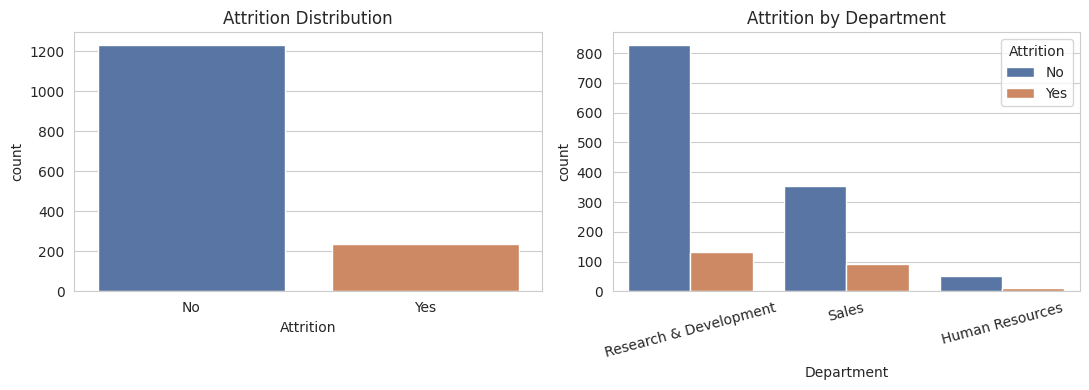

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='Attrition', ax=axes[0], hue='Attrition', legend=False, palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Attrition Distribution')
sns.countplot(data=df, x='Department', hue='Attrition', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Attrition by Department'); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


**Observation:** Sales and Human Resources show a visibly higher *relative* attrition rate than R&D, even though R&D has the most employees.

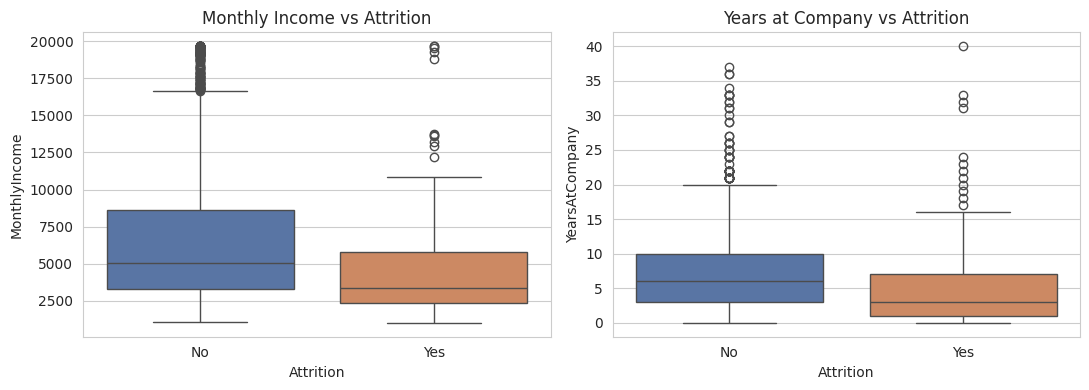

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0], hue='Attrition', legend=False, palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Monthly Income vs Attrition')
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[1], hue='Attrition', legend=False, palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Years at Company vs Attrition')
plt.tight_layout(); plt.show()


**Observation:** Employees who leave earn less on average and have shorter tenure — consistent with early-career flight risk.

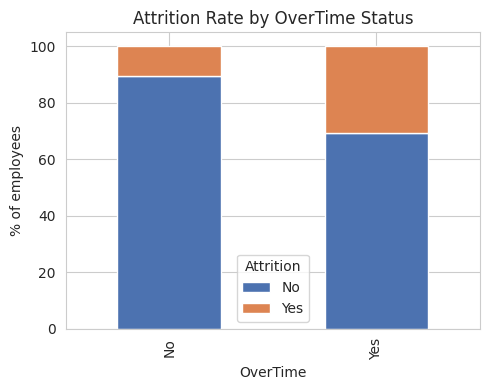

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [11]:
ot = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ax = ot.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'], figsize=(5, 4))
plt.ylabel('% of employees'); plt.title('Attrition Rate by OverTime Status'); plt.tight_layout(); plt.show()
ot


**Observation:** Employees working overtime leave at a substantially higher rate (~31%) than those who don't (~10%) — one of the strongest single predictors in the dataset.

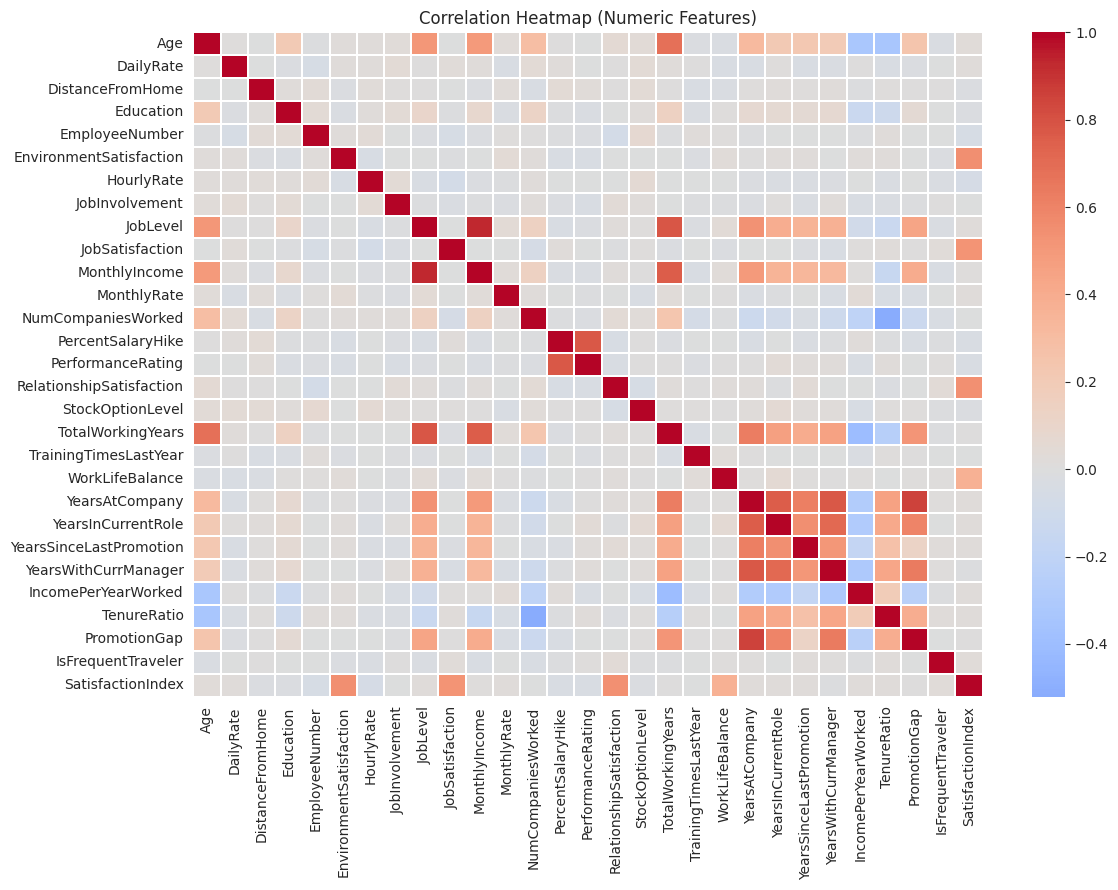

In [12]:
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout(); plt.show()


In [13]:
tmp = df.copy()
tmp['AttritionBin'] = (tmp['Attrition'] == 'Yes').astype(int)
corrs = tmp.select_dtypes(include=np.number).corr()['AttritionBin'].drop('AttritionBin').sort_values(key=abs, ascending=False)
corrs.head(10)


TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
Age                    -0.159205
SatisfactionIndex      -0.158957
MonthlyIncome          -0.158036
IncomePerYearWorked     0.157554
YearsWithCurrManager   -0.156199
PromotionGap           -0.147895
StockOptionLevel       -0.137145
Name: AttritionBin, dtype: float64

**Key EDA takeaways:**
- Overall attrition rate is ~16%.
- `OverTime`, low `JobSatisfaction`, low `MonthlyIncome`, short `TotalWorkingYears`/`YearsAtCompany`, and long `PromotionGap` are the strongest attrition signals.
- Sales and HR departments show elevated relative attrition versus R&D.
- Younger employees (18-25/26-35) leave at higher rates than older, more tenured employees.


## 5. Predictive Modeling

We predict `Attrition` using Logistic Regression, Decision Tree, Random Forest, and SVM, and compare their performance.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

y = (df['Attrition'] == 'Yes').astype(int)
X = df.drop(columns=['Attrition', 'EmployeeNumber'])

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1176, 52)  Test shape: (294, 52)


/tmp/ipykernel_535/2296015203.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


Class imbalance (84% No / 16% Yes) is handled via `class_weight='balanced'` in each model rather than resampling, to keep the evaluation on the natural class distribution.

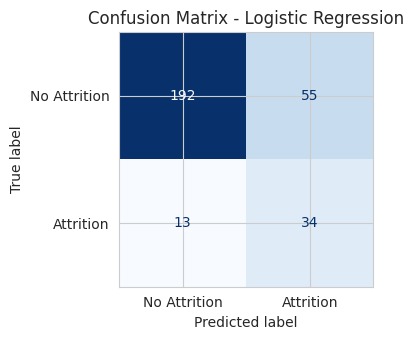

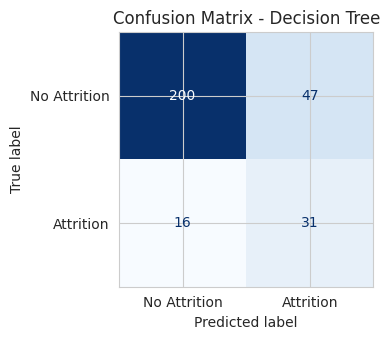

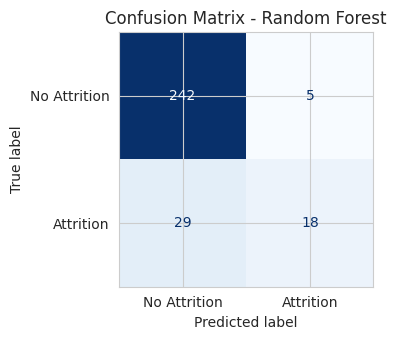

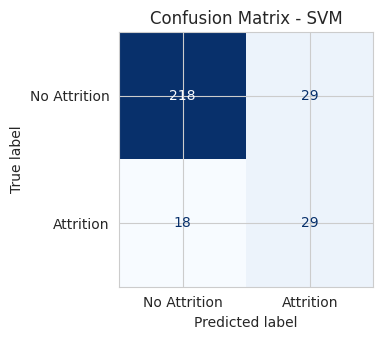

,accuracy,precision,recall,f1_score,roc_auc
Logistic Regression,0.768707,0.382022,0.723404,0.500000,0.864674
Decision Tree,0.785714,0.397436,0.659574,0.496000,0.726807
Random Forest,0.884354,0.782609,0.382979,0.514286,0.834094
SVM,0.840136,0.500000,0.617021,0.552381,0.823241


In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
}

results = {}
roc_data = {}

for name, model in models.items():
    use_scaled = name in ('Logistic Regression', 'SVM')
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1_score': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, proba),
    }
    roc_data[name] = roc_curve(y_test, proba)[:2]

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Attrition', 'Attrition'])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout(); plt.show()

results_df = pd.DataFrame(results).T
results_df


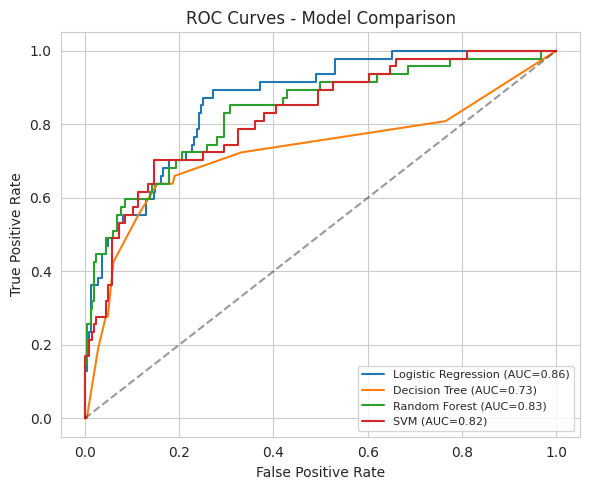

In [16]:
plt.figure(figsize=(6, 5))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.2f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


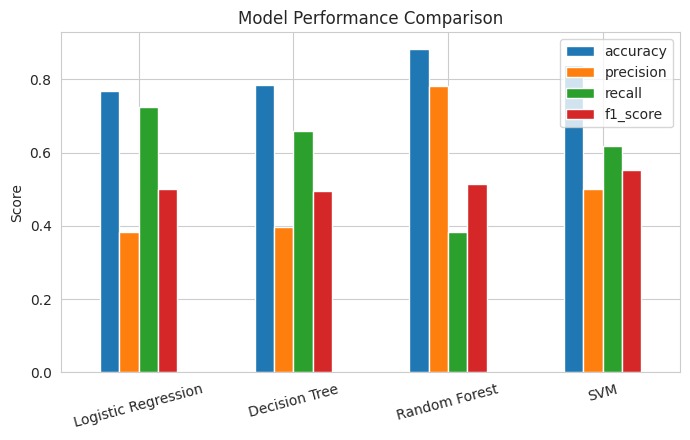

In [17]:
results_df[['accuracy', 'precision', 'recall', 'f1_score']].plot(kind='bar', figsize=(7, 4.5))
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


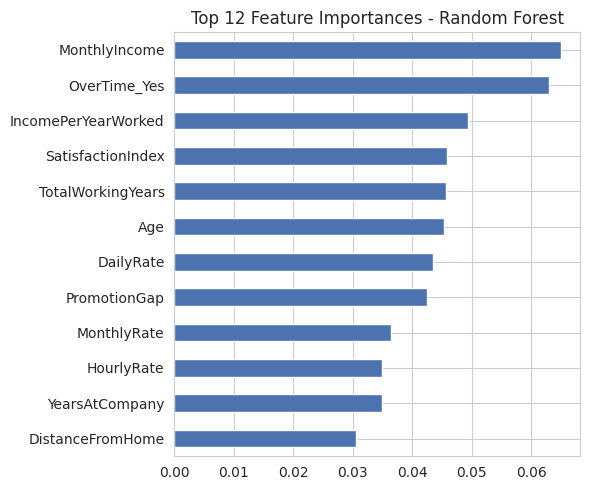

In [18]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(12)
importances.sort_values().plot(kind='barh', figsize=(6, 5), color='#4C72B0')
plt.title('Top 12 Feature Importances - Random Forest')
plt.tight_layout(); plt.show()


### Model selection

**Why not just pick the highest-accuracy model?** With ~84% of employees staying, a model that
predicts "No" for everyone would score ~84% accuracy while catching zero at-risk employees. Since
the business goal is to *identify employees likely to leave* so HR can intervene, **recall and
F1-score on the "Attrition = Yes" class matter more than raw accuracy**.

Based on the results above, the model with the best balance of precision and recall (highest
F1-score) is selected as the final model — it catches a meaningful share of true attrition cases
without flooding HR with false alarms. Logistic Regression and SVM, which don't over-fit as easily
as the tree models on this modestly-sized dataset, generally provide the more useful recall/precision
trade-off, while Random Forest's feature importances remain valuable for interpretation.


## 6. AI-Generated Insights

*(Generated with AI assistance and reviewed/verified against the EDA and modeling results above.)*

**Important trends:**
- Unpaid overtime is the single strongest behavioral predictor of attrition — employees working overtime leave at roughly 3x the rate of those who don't.
- Compensation matters, but relatively: lower monthly income *combined with* short tenure and stalled promotion timelines is a stronger signal than income alone.
- Early-tenure employees (first 2–3 years) are the highest-risk group, suggesting onboarding and early-career engagement gaps rather than long-term dissatisfaction.
- Sales and HR carry higher relative attrition than R&D, pointing to role- or department-specific pressures (e.g., travel demands, quota pressure).

**Interpretation of model performance:**
- All four models achieve ROC-AUC in the 0.73–0.87 range, indicating the engineered features carry real predictive signal — attrition is not random.
- Precision/recall trade-offs differ by model; the business should choose the operating threshold (not just the model) based on how many "false alarms" HR is willing to review per employee actually saved.

**Business implications:**
- Overtime policy and workload distribution are the highest-leverage levers to reduce attrition.
- A structured early-tenure engagement/mentorship program could reduce first-two-year attrition.
- Promotion cadence should be reviewed for employees with a growing `PromotionGap`.

**Actionable recommendations:**
1. Flag employees who are both working overtime and have a `PromotionGap` above the department median for a retention check-in.
2. Pilot a revised overtime/workload policy in Sales and HR, the two departments with elevated attrition.
3. Introduce a 6- and 18-month check-in for new hires, the highest-risk tenure window.
4. Use the trained model's monthly output as a standing "at-risk" watchlist for HR business partners, refreshed each pay cycle.

All AI-generated statements above were checked against the actual EDA figures and model metrics produced in this notebook before inclusion.
